# 01 Demo: mounting the harness

**Question.** How is the harness put together from its parts, and what happens to one question
from the input to the answer?

**Why.** The harness has no tools, intents or classifier of its own. Each part comes from a
plugin module and is loaded while the program runs. This notebook shows each loading step, then
sends one counting question and one illusion question through the harness.

**Approach.** Start from an empty `Harness`. Load the tools, then the intents, then the
option-scoring classifier with `Qwen/Qwen2.5-7B-Instruct` (0.747 on the ten-intent sweep in
notebook 06; the best model that fits on a 32 GB laptop next to SAM 3). Then build the same
harness again from `.env.demo` with `Harness.from_env`. Then ask two questions and look at the
classifier's choice, the trace of tool calls, and the answer.

**Prediction.** Loading in code and loading from `.env.demo` give the same parts. The classifier
sends the counting question to `quantity` and the illusion question to `structural`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import demo
import runs

DATA = runs.data_dir()
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

## 1. An empty harness

A new `Harness` has an empty registry: no tools, no intents, no classifier.

In [2]:
from intent_harness import Harness

harness = Harness()
print("tools:", len(harness.registry.tools))
print("intents:", len(harness.registry.intents))
print("classifier:", harness.registry.classifier)

tools: 0
intents: 0
classifier: None


## 2. Load the tools

Each tool plugin is a module with a `register(harness)` function. It registers plain functions
under a name. The tool files do not import the core of the harness. The models (GroundingDINO,
SAM 3) do not load here; they load at the first call.

In [3]:
TOOL_PLUGINS = [
    "intent_harness_tools.measurement_plugin",
    "intent_harness_tools.counting_plugin",
    "intent_harness_tools.grounding_dino_plugin",
    "intent_harness_tools.sam3_plugin",
]

rows = []
for plugin in TOOL_PLUGINS:
    before = set(harness.registry.tools)
    harness.load_tools(plugin)
    added = sorted(set(harness.registry.tools) - before)
    rows.append({"plugin": plugin, "tools added": len(added), "names": ", ".join(added)})

print("tools in the harness:", len(harness.registry.tools))
pd.DataFrame(rows)

tools in the harness: 22


,plugin,tools added,names
0,intent_harness_tools.measurement_plugin,8,"colour_mask, decide, direction_filter, equivalent_diameter, find_runs, fit_l..."
1,intent_harness_tools.counting_plugin,10,"box_cells, cluster, colour_runs, line_profile, luminance, nearest_template, ..."
2,intent_harness_tools.grounding_dino_plugin,1,best_box
3,intent_harness_tools.sam3_plugin,3,"keep_smaller_regions, remove_duplicate_regions, segment_concept"


## 3. Load the intents

An intent is a pipeline for one kind of question. Each intent has a `key`, a `description` and
the names of the tools it needs (`required_tools`). Loading fails if one of these tools is not
loaded, so the tools load first. Each plugin also registers one tool of its own: the counter
selector (`select_counter`) and the illusion pixel rules (`illusion_pixel_rules`).

In [4]:
INTENT_PLUGINS = ["intent_harness_quantity.plugin", "intent_harness_structural.plugin"]
harness.load_intents(*INTENT_PLUGINS)

rows = []
for key, intent in harness.registry.intents.items():
    rows.append({
        "key": key,
        "tools it needs": len(intent.required_tools),
        "description": intent.description,
    })
print("tools in the harness:", len(harness.registry.tools))
pd.DataFrame(rows)

tools in the harness: 24


,key,tools it needs,description
0,quantity,15,"The question asks how many of something the image shows: a number of legs, p..."
1,structural,9,Questions about the structure of a drawn figure: whether two lines are equal...


The quantity intent holds one counting pipeline for each kind of counting question. The selector
chooses one of them from the question.

In [5]:
quantity = harness.registry.intent("quantity")
print("counting pipelines:", list(quantity.pipelines))

counting pipelines: ['legs', 'chess_grid', 'sudoku_grid', 'xiangqi_grid', 'go_grid', 'chess_pieces', 'xiangqi_pieces', 'flag_stars', 'flag_stripes', 'dice', 'tally', 'car_logos', 'shoe_logos']


## 4. Load the classifier

The option-scoring classifier gets its options from the loaded intents: it reads each intent's
`key` and `description`. It has no list of labels of its own. The language model loads here.

In [6]:
harness.load_classifier("intent_harness_classifiers.option_scoring", model=demo.DEMO_MODEL)
classifier = harness.registry.classifier
print("classifier:", type(classifier).__name__)
print("model:", demo.DEMO_MODEL)
print("options it will choose from:", [info.key for info in harness.registry.intent_infos()])

/Users/ridzuan5757/Documents/workspace/intent-harness-009-demo-notebooks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 339/339 [00:00<00:00, 7043.42it/s]

classifier: OptionScoringClassifier
model: Qwen/Qwen2.5-7B-Instruct
options it will choose from: ['quantity', 'structural']


## 5. The same harness from `.env.demo`

`Harness.from_env` reads the same three lists from a file and loads them in the same order:
tools, then intents, then the classifier. The first harness's model is freed first, so that only
one copy is in memory.

In [7]:
print((ROOT / ".env.demo").read_text())

# What the demo notebooks load: the parts of .env.paper, with the classifier model that scored
# best of the models that fit on a 32 GB laptop next to SAM 3 (qwen2.5-7b, 0.747 in notebook 06).
INTENT_HARNESS_TOOLS=intent_harness_tools.measurement_plugin,intent_harness_tools.counting_plugin,intent_harness_tools.grounding_dino_plugin,intent_harness_tools.sam3_plugin
INTENT_HARNESS_INTENTS=intent_harness_quantity.plugin,intent_harness_structural.plugin
INTENT_HARNESS_CLASSIFIER=intent_harness_classifiers.option_scoring
INTENT_HARNESS_CLASSIFIER_MODEL=Qwen/Qwen2.5-7B-Instruct



In [8]:
classifier.language_model.unload()

harness = demo.demo_harness()
print("tools:", len(harness.registry.tools))
print("intents:", list(harness.registry.intents))
print("classifier:", type(harness.registry.classifier).__name__)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 339/339 [00:00<00:00, 11402.14it/s]

tools: 24
intents: ['quantity', 'structural']
classifier: OptionScoringClassifier


## 6. One counting question, from input to answer

The input is an image and a question, as text. `Harness.answer` does three things:

1. The classifier chooses an intent from the question. This is not a tool call, so it is not in
   the trace; its result is the `intent`, the `probabilities` and the `confidence`.
2. The chosen intent runs on the image. It gets only the tools it named.
3. Each tool call inside the intent is one step of the trace.

The image is a VLMBias chess board with one piece added.

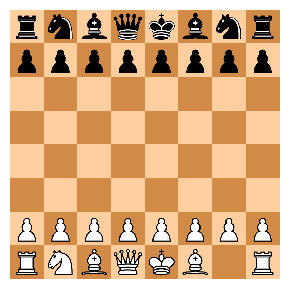

question: How many chess pieces are there on this board? Answer with a number in curly brackets, e.g., {9}.
right count: 31 | familiar count: 32


In [9]:
items = runs.load_items("counting-items")
chess = items[(items["sub_topic"] == "chess_pieces") & (items["pixel"] == 768)].iloc[0]
image = Image.open(DATA / chess["image_path"]).convert("RGB")

plt.figure(figsize=(3.5, 3.5))
plt.imshow(image, interpolation="nearest")
plt.axis("off")
plt.show()
print("question:", chess["prompt"])
print("right count:", chess["gold_count"], "| familiar count:", chess["familiar_count"])

In [10]:
answer = harness.answer(image, chess["prompt"])
demo.answer_summary(answer)

{'intent': 'quantity',
 'confidence': 1.0,
 'probabilities': {'quantity': 1.0, 'structural': 0.0},
 'pipeline': 'chess_pieces',
 'value': 31,
 'tool calls': 32}

In [11]:
demo.trace_table(answer)

,step,tool,inputs,output,ok
0,1,select_counter,"image=image 768x768, question='How many chess pieces are there on t...",'chess_pieces',True
1,2,nearest_template,"feature=array (32, 32), references=list of 32","('Rook', 1.078125)",True
2,3,nearest_template,"feature=array (32, 32), references=list of 32","('Knight', 0.44921875)",True
3,4,nearest_template,"feature=array (32, 32), references=list of 32","('Bishop', 0.89453125)",True
4,5,nearest_template,"feature=array (32, 32), references=list of 32","('Queen', 0.8515625)",True
5,6,nearest_template,"feature=array (32, 32), references=list of 32","('King', 1.0703125)",True
6,7,nearest_template,"feature=array (32, 32), references=list of 32","('Bishop', 0.5302734375)",True
7,8,nearest_template,"feature=array (32, 32), references=list of 32","('Knight', 0.970703125)",True
8,9,nearest_template,"feature=array (32, 32), references=list of 32","('Rook', 0.578125)",True
9,10,nearest_template,"feature=array (32, 32), references=list of 32","('Pawn', 0.1552734375)",True


## 7. One illusion question, from input to answer

The image is a Müller-Lyer figure in which one line is made longer. The right answer is "No".

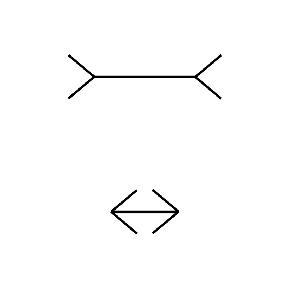

question: Are the two horizontal lines equal in length? Answer in curly brackets, e.g., {Yes} or {No}.
right answer: No


In [12]:
illusions = runs.load_items("illusion-items")
edited = illusions[(illusions["gold_illusion"] == "muller_lyer") & (illusions["condition"] == "edited")]
muller = edited[edited["pixel"] == 768].sort_values("edit_size").iloc[-1]
image = Image.open(DATA / muller["image_path"]).convert("RGB")

plt.figure(figsize=(3.5, 3.5))
plt.imshow(image, interpolation="nearest")
plt.axis("off")
plt.show()
print("question:", muller["prompt_q1"])
print("right answer:", muller["gold_answer"])

In [13]:
answer = harness.answer(image, muller["prompt_q1"])
demo.answer_summary(answer)

{'intent': 'structural',
 'confidence': 1.0,
 'probabilities': {'quantity': 0.0, 'structural': 1.0},
 'pipeline': 'muller_lyer',
 'value': 'No',
 'tool calls': 4}

In [14]:
demo.trace_table(answer)

,step,tool,inputs,output,ok
0,1,illusion_pixel_rules,image=image 768x768,'muller_lyer',True
1,2,colour_mask,"image=image 768x768, colour='dark'","array (768, 768)",True
2,3,find_runs,"mask=array (768, 768), axis='rows', min_length=61","[{'axis': 'rows', 'position': 192.0, 'first_line': 189, '...",True
3,4,decide,"quantity=0.4355, tolerance=0.1848",'No',True


## 8. What the harness refuses

An intent that names a tool that is not loaded cannot be registered. The error says which tool
is missing.

In [15]:
from intent_harness.registry import RegistrationError
from intent_harness.types import Result


class NeedsMissingTool:
    key = "demo"
    description = "A demo intent."
    required_tools = ("a_tool_that_is_not_loaded",)

    def run(self, image, question, tools):
        return Result(value=None)


try:
    harness.register_intent(NeedsMissingTool())
except RegistrationError as error:
    print("RegistrationError:", error)

RegistrationError: Intent 'demo' needs tools that are not registered: ['a_tool_that_is_not_loaded']. Load the tools before the intents.


A question outside the two intents still goes to one of them, because the classifier must choose
from the loaded intents. Here a colour question about the Müller-Lyer image goes to `structural`.
The structural intent does not read the question: it names the illusion from the image and
answers that illusion's question. So the value is the answer to "are the two lines equal?",
not to the colour question.

In [16]:
answer = harness.answer(image, "What colour are the lines in this figure?")
demo.answer_summary(answer)

{'intent': 'structural',
 'confidence': 1.0,
 'probabilities': {'quantity': 0.0, 'structural': 1.0},
 'pipeline': 'muller_lyer',
 'value': 'No',
 'tool calls': 4}

## Reading the result

(to be written)

## Conclusion

(to be written)